In [1]:
import os
import sys
import pandas as pd

In [2]:
sys.path.append(os.path.abspath('../../'))
from src.data_loader import DataLoader
from src.database_utils import Database

In [3]:
local_path = '/Users/ljob/Desktop/'

# Path to the SFS reforecast database
database = local_path + 'Data/SFS_reforecast/sfs_reforecast_data.db'
table = 'reforecast_data'

In [4]:
# Read in data from SFS reforecast database
df = Database(database, table).load()

In [5]:
# Only processed latent_heat_flux so we now will use that and air_temperature to calculate evaporation

def calculate_evaporation(df):
    """
    Calculate monthly evaporation from latent heat flux and air temperature
    for each ensemble member.

    Required columns:
        init_time
        member
        lead
        valid_time
        lake
        surface_type
        component
        value

    Returns:
        DataFrame with evaporation in mm/month for each ensemble member.
    """

    df = df.copy()

    # Make sure times are datetime
    df["valid_time"] = pd.to_datetime(df["valid_time"])
    df["init_time"] = pd.to_datetime(df["init_time"])

    # ------------------------------------------------------------------
    # Get temperature and latent heat flux for each ensemble member
    # ------------------------------------------------------------------

    calc_df = (
        df[
            df["component"].isin(
                ["air_temperature", "latent_heat_flux"]
            )
        ]
        .pivot_table(
            index=[
                "init_time",
                "member",
                "lead",
                "valid_time",
                "lake",
                "surface_type"
            ],
            columns="component",
            values="value",
            aggfunc="first"
        )
        .reset_index()
    )
    
    # ------------------------------------------------------------------
    # Check that both variables are available
    # ------------------------------------------------------------------

    required = [
        "air_temperature",
        "latent_heat_flux"
    ]

    missing = calc_df[required].isna().any(axis=1)

    if missing.any():

        missing_rows = calc_df.loc[
            missing,
            [
                "init_time",
                "member",
                "lead",
                "valid_time",
                "lake",
                "surface_type"
            ] + required
        ]

        print(
            f"Warning: {missing_rows.shape[0]} ensemble combinations "
            "are missing temperature or latent heat flux. Dropping these rows from evaporation calculation."
        )

        #print(missing_rows.head(20))

    # ------------------------------------------------------------------
    # Only calculate evaporation where both variables exist
    # ------------------------------------------------------------------

    calc_df = calc_df.dropna(
        subset=required
    ).copy()

    # ------------------------------------------------------------------
    # Convert temperature from Kelvin to Celsius
    # ------------------------------------------------------------------

    temperature_C = (
        calc_df["air_temperature"] - 273.15
    )

    # ------------------------------------------------------------------
    # Latent heat of vaporization
    # ------------------------------------------------------------------

    lambda_MJ_kg = (
        2.501 - 0.002361 * temperature_C
    )

    # ------------------------------------------------------------------
    # Convert latent heat flux:
    # W/m² -> MJ/(s m²)
    # ------------------------------------------------------------------

    latent_heat_flux_MJ = (
        calc_df["latent_heat_flux"] * 1e-6
    )

    # ------------------------------------------------------------------
    # Calculate evaporation rate:
    # MJ/(s m²) / MJ/kg = kg/(m² s) = mm/s
    # ------------------------------------------------------------------

    evaporation_rate_mm_s = (
        latent_heat_flux_MJ / lambda_MJ_kg
    )

    # ------------------------------------------------------------------
    # Calculate seconds in each month
    # ------------------------------------------------------------------

    days_in_month = (
        calc_df["valid_time"].dt.days_in_month
    )

    seconds_in_month = (
        days_in_month * 24 * 60 * 60
    )

    # ------------------------------------------------------------------
    # Convert mm/s -> mm/month
    # ------------------------------------------------------------------

    calc_df["evaporation"] = (
        evaporation_rate_mm_s * seconds_in_month
    )

    # ------------------------------------------------------------------
    # Return member-level evaporation
    # ------------------------------------------------------------------

    evaporation_df = calc_df[
        [
            "init_time",
            "member",
            "lead",
            "valid_time",
            "lake",
            "surface_type",
            "evaporation"
        ]
    ].copy()

    return evaporation_df

In [6]:
evap_df = calculate_evaporation(df)

In [7]:
print(evap_df)

component  init_time  member  lead valid_time            lake surface_type  \
0         1991-03-01       0     0 1991-03-01            erie         lake   
1         1991-03-01       0     0 1991-03-01            erie         land   
2         1991-03-01       0     0 1991-03-01  michigan-huron         lake   
3         1991-03-01       0     0 1991-03-01  michigan-huron         land   
4         1991-03-01       0     0 1991-03-01         ontario         lake   
...              ...     ...   ...        ...             ...          ...   
294619    2025-11-01      10    11 2026-10-01  michigan-huron         land   
294620    2025-11-01      10    11 2026-10-01         ontario         lake   
294621    2025-11-01      10    11 2026-10-01         ontario         land   
294622    2025-11-01      10    11 2026-10-01        superior         lake   
294623    2025-11-01      10    11 2026-10-01        superior         land   

component  evaporation  
0             6.273003  
1            

In [15]:
# Format the evaporation dataframe to match the original dataframe structure
# and add it back in to the original dataframe
evap_df = evap_df.copy()

# Rename the evaporation column to "value" to match the original dataframe
evap_df = evap_df.rename(
    columns={"evaporation": "value"}
)

# Create a new column for the component name
evap_df["component"] = "evaporation"

# Add evaporation rows to original dataframe
df_merged = pd.concat(
    [df, evap_df],
    ignore_index=True
)
# Make sure times are datetime in the same format
df_merged["init_time"] = pd.to_datetime(
    df_merged["init_time"]
).dt.strftime("%Y-%m-%d")

df_merged["valid_time"] = pd.to_datetime(
    df_merged["valid_time"]
).dt.strftime("%Y-%m-%d")

# Sort
df_merged = df_merged.sort_values(
    by=[
        "init_time",
        "member",
        "lead",
        "valid_time",
        "lake",
        "surface_type",
        "component"
    ]
).reset_index(drop=True)

sfs_data = df_merged.copy()

In [ ]:
sfs_stats = (
    sfs_data.groupby(
        ["valid_time", "lake", "surface_type", "component"]
    )["value"]
    .agg(
        mean="mean",
        q5=lambda x: x.quantile(0.05),
        q95=lambda x: x.quantile(0.95)
    )
    .reset_index()
)
print(sfs_stats)

       valid_time      lake surface_type         component        mean  \
0      1991-03-01      erie         lake   air_temperature  273.368203   
1      1991-03-01      erie         lake       evaporation    8.088611   
2      1991-03-01      erie         lake  latent_heat_flux    7.555303   
3      1991-03-01      erie         lake     precipitation  114.652104   
4      1991-03-01      erie         land   air_temperature  274.628113   
...           ...       ...          ...               ...         ...   
13691  2026-10-01  superior         lake     precipitation   74.656876   
13692  2026-10-01  superior         land   air_temperature  278.482122   
13693  2026-10-01  superior         land       evaporation   24.206170   
13694  2026-10-01  superior         land  latent_heat_flux   22.489243   
13695  2026-10-01  superior         land     precipitation   74.270104   

               q5         q95  
0      272.229279  274.575378  
1       -0.671362   15.863930  
2       -0.6246

In [10]:
# READ IN CFSR DATA
cfsr_file = '/Users/ljob/Desktop/Data/cfsr/CFSR_archived_1979-2024.csv'
cfsr_data = pd.read_csv(cfsr_file,sep=',')

In [21]:
# READ IN CFS REFORECAST DATA
cfs_reforecast_file = '/Users/ljob/Desktop/Data/CFS_Reforecast/cfs_reforecast_data_new_format.db'
cfs_reforecast_table = 'cfs_reforecast_data'

cfsref_data = Database(cfs_reforecast_file, cfs_reforecast_table).load()

In [ ]:
cfsref_stats = (
    cfsref_data.groupby(
        ["valid_time", "lake", "surface_type", "component"]
    )["value"]
    .agg(
        mean="mean",
        q5=lambda x: x.quantile(0.05),
        q95=lambda x: x.quantile(0.95)
    )
    .reset_index()
)
print(cfsref_stats)

      valid_time      lake surface_type        component        mean  \
0     1981-12-01      erie         lake  air_temperature  268.765452   
1     1981-12-01      erie         lake      evaporation   50.674623   
2     1981-12-01      erie         lake    precipitation  109.036087   
3     1981-12-01      erie         land  air_temperature  267.734191   
4     1981-12-01      erie         land      evaporation   32.010139   
...          ...       ...          ...              ...         ...   
8683  2012-01-01  superior         lake      evaporation   81.967533   
8684  2012-01-01  superior         lake    precipitation   67.291936   
8685  2012-01-01  superior         land  air_temperature  259.463482   
8686  2012-01-01  superior         land      evaporation   37.959474   
8687  2012-01-01  superior         land    precipitation   55.044193   

              q5         q95  
0     267.368118  270.226484  
1      39.649040   60.421696  
2      78.993435  182.914290  
3     266.3

In [13]:
# Load L2SWBM data
dataloader = DataLoader()
l2_data = dataloader.l2swbm('/Users/ljob/Desktop/cnbs-predictor/data/l2swbm/')
l2_data = l2_data.reset_index()

In [16]:
obs_long = l2_data.melt(
    id_vars="date",
    var_name="variable",
    value_name="obs"
)

# Split on "_"
obs_long[["lake", "component", "suffix"]] = (
    obs_long["variable"].str.split("_", expand=True)
)

# Remove the "_obs" suffix column
obs_long = obs_long.drop(columns=["suffix", "variable"])

print(obs_long)

            date         obs      lake      component
0     1950-01-01  125.357918  superior    evaporation
1     1950-02-01   70.413371  superior    evaporation
2     1950-03-01   42.505142  superior    evaporation
3     1950-04-01   25.310708  superior    evaporation
4     1950-05-01   -8.965747  superior    evaporation
...          ...         ...       ...            ...
10507 2022-08-01   84.000000   ontario  precipitation
10508 2022-09-01   65.400000   ontario  precipitation
10509 2022-10-01   32.100000   ontario  precipitation
10510 2022-11-01   86.500000   ontario  precipitation
10511 2022-12-01  117.000000   ontario  precipitation

[10512 rows x 4 columns]


In [19]:
sfs_data["valid_time"] = pd.to_datetime(sfs_data["valid_time"])
obs_long["date"] = pd.to_datetime(obs_long["date"])

sfs_ver = sfs_data.merge(
    obs_long,
    left_on=["valid_time", "lake", "component"],
    right_on=["date", "lake", "component"],
    how="inner"
)
sfs_ver = sfs_ver.drop(columns=["date"])
print(sfs_ver)

         init_time  member  lead valid_time            lake surface_type  \
0       1991-03-01       0     0 1991-03-01            erie         lake   
1       1991-03-01       0     0 1991-03-01            erie         lake   
2       1991-03-01       0     0 1991-03-01            erie         land   
3       1991-03-01       0     0 1991-03-01            erie         land   
4       1991-03-01       0     0 1991-03-01  michigan-huron         lake   
...            ...     ...   ...        ...             ...          ...   
532691  2022-11-01      10     1 2022-12-01         ontario         land   
532692  2022-11-01      10     1 2022-12-01        superior         lake   
532693  2022-11-01      10     1 2022-12-01        superior         lake   
532694  2022-11-01      10     1 2022-12-01        superior         land   
532695  2022-11-01      10     1 2022-12-01        superior         land   

            component       value         obs  
0         evaporation    6.273003   15.

In [22]:
cfsref_data["valid_time"] = pd.to_datetime(cfsref_data["valid_time"])
obs_long["date"] = pd.to_datetime(obs_long["date"])

cfsref_ver = cfsref_data.merge(
    obs_long,
    left_on=["valid_time", "lake", "component"],
    right_on=["date", "lake", "component"],
    how="inner"
)
cfsref_ver = cfsref_ver.drop(columns=["date"])
print(cfsref_ver)

             init_time  lead valid_time            lake surface_type  \
0        1981-12-12 00     0 1981-12-01            erie         lake   
1        1981-12-12 00     0 1981-12-01            erie         land   
2        1981-12-12 00     0 1981-12-01         ontario         lake   
3        1981-12-12 00     0 1981-12-01         ontario         land   
4        1981-12-12 00     0 1981-12-01  michigan-huron         lake   
...                ...   ...        ...             ...          ...   
1136235  2011-03-17 18    10 2012-01-01         ontario         land   
1136236  2011-03-17 18    10 2012-01-01  michigan-huron         lake   
1136237  2011-03-17 18    10 2012-01-01  michigan-huron         land   
1136238  2011-03-17 18    10 2012-01-01        superior         lake   
1136239  2011-03-17 18    10 2012-01-01        superior         land   

             component      value         obs  
0          evaporation  54.864594   99.675632  
1          evaporation  34.814938   99.

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd


def plot_forecast_timeseries(
    df,
    CFSR_data,
    cfs_reforecast,
    observations
):
    """
    Plot forecast, CFS reforecast, CFSR, and observations.

    Rows:
        Lakes

    Columns:
        Components

    Line styles:
        Lake = solid
        Land = dashed

    Data:
        df:
            Main forecast mean + q5/q95

        cfs_reforecast:
            CFS reforecast mean + q5/q95

        CFSR_data:
            Historical CFSR values

        observations:
            Over-lake observations
    """

    # ------------------------------------------------------------------
    # Settings
    # ------------------------------------------------------------------

    lakes = [
        "superior",
        "michigan-huron",
        "erie",
        "ontario",
    ]

    components = [
        "precipitation",
        "evaporation",
        "air_temperature",
    ]

    surface_types = [
        #"land",
        "lake"
    ]

    # ------------------------------------------------------------------
    # Prepare main forecast dataframe
    # ------------------------------------------------------------------

    df = df.copy()

    df["valid_time"] = pd.to_datetime(
        df["valid_time"]
    )

    # ------------------------------------------------------------------
    # Prepare CFS reforecast dataframe
    # ------------------------------------------------------------------

    cfs_reforecast = cfs_reforecast.copy()

    cfs_reforecast["valid_time"] = pd.to_datetime(
        cfs_reforecast["valid_time"]
    )

    # ------------------------------------------------------------------
    # Prepare CFSR dataframe
    # ------------------------------------------------------------------

    CFSR_data = CFSR_data.copy()

    CFSR_data["date"] = pd.to_datetime(
        CFSR_data["date"]
    )

    # ------------------------------------------------------------------
    # Prepare observations dataframe
    # ------------------------------------------------------------------

    observations = observations.copy()

    observations["date"] = pd.to_datetime(
        observations["date"]
    )

    # ------------------------------------------------------------------
    # Create figure
    # ------------------------------------------------------------------

    fig, axes = plt.subplots(
        nrows=4,
        ncols=3,
        figsize=(18, 13),
        sharex=True
    )

    # ==================================================================
    # Loop through lakes
    # ==================================================================

    for i, lake in enumerate(lakes):

        for j, component in enumerate(components):

            ax = axes[i, j]

            # ==========================================================
            # Main forecast
            # ==========================================================

            plot_df = df[
                (df["lake"] == lake) &
                (df["component"] == component)
            ].copy()

            plot_df = plot_df.sort_values(
                "valid_time"
            )

            for surface_type in surface_types:

                surface_df = plot_df[
                    plot_df["surface_type"] == surface_type
                ].copy()

                if surface_df.empty:
                    continue

                surface_df = surface_df.sort_values(
                    "valid_time"
                )

                # Lake = solid
                # Land = dashed
                if surface_type == "lake":
                    linestyle = "-"
                else:
                    linestyle = "--"

                # ------------------------------------------------------
                # Main forecast mean
                # ------------------------------------------------------

                ax.plot(
                    surface_df["valid_time"],
                    surface_df["mean"],
                    linewidth=1.5,
                    linestyle=linestyle,
                    color="red",
                    label=f"SFS Forecast"
                )

                # ------------------------------------------------------
                # Main forecast uncertainty
                # ------------------------------------------------------

                ax.fill_between(
                    surface_df["valid_time"],
                    surface_df["q5"],
                    surface_df["q95"],
                    color="red",
                    alpha=0.10
                )

                # ======================================================
                # CFS Reforecast
                # ======================================================

                reforecast_df = cfs_reforecast[
                    (cfs_reforecast["lake"] == lake) &
                    (cfs_reforecast["component"] == component) &
                    (cfs_reforecast["surface_type"] == surface_type)
                ].copy()

                if not reforecast_df.empty:

                    reforecast_df = reforecast_df.sort_values(
                        "valid_time"
                    )

                    # --------------------------------------------------
                    # CFS reforecast mean
                    # --------------------------------------------------

                    ax.plot(
                        reforecast_df["valid_time"],
                        reforecast_df["mean"],
                        linewidth=1.5,
                        linestyle=linestyle,
                        alpha=0.8,
                        color="blue",
                        label=f"CFS Reforecast"
                    )

                    # --------------------------------------------------
                    # CFS reforecast uncertainty
                    # --------------------------------------------------

                    ax.fill_between(
                        reforecast_df["valid_time"],
                        reforecast_df["q5"],
                        reforecast_df["q95"],
                        alpha=0.10
                    )

                # ======================================================
                # CFSR
                # ======================================================

                CFSR_column = (
                    f"{lake}_{surface_type}_{component}"
                )

                if CFSR_column in CFSR_data.columns:

                    ax.plot(
                        CFSR_data["date"],
                        CFSR_data[CFSR_column],
                        linewidth=1.5,
                        linestyle=linestyle,
                        alpha=0.8,
                        color="green",
                        label=f"CFSR"
                    )

            # ==========================================================
            # Over-lake observations
            # ==========================================================

            obs_column = (
                f"{lake}_{component}_obs"
            )

            if obs_column in observations.columns:

                obs_df = observations[
                    ["date", obs_column]
                ].dropna().copy()

                obs_df = obs_df.sort_values(
                    "date"
                )

                ax.plot(
                    obs_df["date"],
                    obs_df[obs_column],
                    color="black",
                    linewidth=2.5,
                    linestyle="-",
                    label="Observed"
                )

            # ==========================================================
            # Formatting
            # ==========================================================

            ax.grid(
                alpha=0.3
            )

            ax.set_xlim(
                pd.Timestamp("2000-01-01"),
                pd.Timestamp("2005-01-01")
            )

            # Remove subplot titles
            ax.set_title("")

            # Only show x labels on bottom row
            if i != len(lakes) - 1:
                ax.tick_params(
                    labelbottom=False
                )

            # Remove interior y-axis labels
            if j != 0:
                ax.tick_params(
                    labelleft=False
                )

    # ==================================================================
    # Component titles across top
    # ==================================================================

    for j, component in enumerate(components):

        axes[0, j].set_title(
            component.replace("_", " ").title(),
            fontsize=14,
            fontweight="bold",
            pad=12
        )

    # ==================================================================
    # Lake labels along left
    # ==================================================================

    for i, lake in enumerate(lakes):

        axes[i, 0].text(
            -0.22,
            0.5,
            lake.replace("-", "\n").title(),
            transform=axes[i, 0].transAxes,
            rotation=90,
            va="center",
            ha="center",
            fontsize=13,
            fontweight="bold"
        )

    # Rotate x-axis labels for better readability
    for ax in axes[-1, :]:
        ax.tick_params(
            axis="x",
            labelrotation=45,
            labelsize=11
        )
    # ==================================================================
    # Legend
    # ==================================================================

    handles, labels = [], []

    for ax in axes.flat:

        ax_handles, ax_labels = ax.get_legend_handles_labels()

        handles.extend(ax_handles)
        labels.extend(ax_labels)

    # Remove duplicate legend entries
    legend_dict = {}

    for handle, label in zip(handles, labels):

        if label not in legend_dict:
            legend_dict[label] = handle

    fig.legend(
        legend_dict.values(),
        legend_dict.keys(),
        loc="lower center",
        ncol=5,
        bbox_to_anchor=(0.5, 0.005),
        frameon=False
    )

    # ==================================================================
    # Layout
    # ==================================================================

    plt.subplots_adjust(
        left=0.10,
        right=0.98,
        top=0.94,
        bottom=0.12,
        wspace=0.12,
        hspace=0.18
    )

    plt.show()

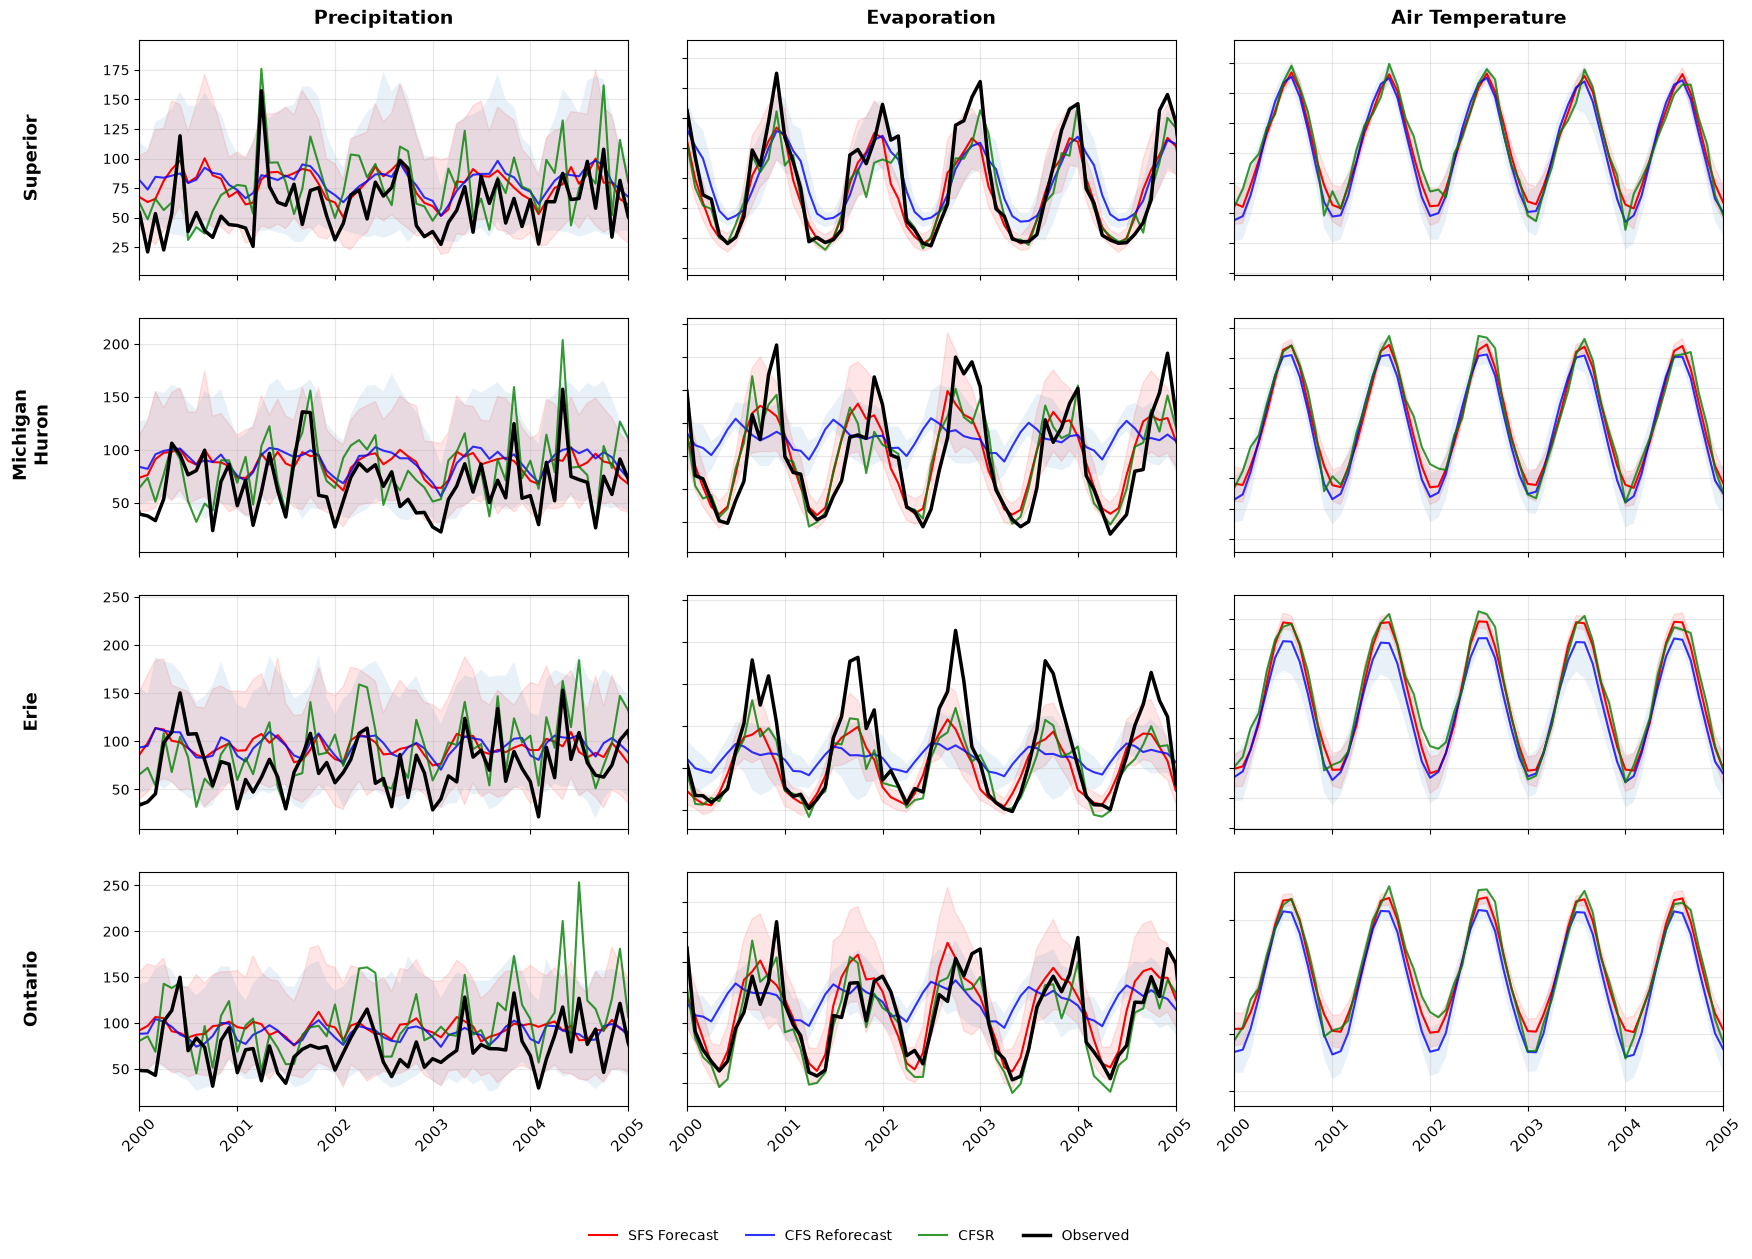

In [133]:
plot_forecast_timeseries(
    forecast_stats,
    cfsr_data,
    cfsref_stats,
    l2_data
)

In [25]:
import numpy as np
import pandas as pd
from properscoring import crps_ensemble
from sklearn.metrics import mean_squared_error, r2_score

def calculate(obs, pred, ens):

    if len(obs) == 0:
        return pd.Series({
            "RMSE": np.nan,
            "R2": np.nan,
            "Bias": np.nan,
            "VarRatio": np.nan,
            "NSE": np.nan,
            "KGE": np.nan,
            "CRPS": np.nan
        })

    # RMSE
    rmse = np.sqrt(
        mean_squared_error(obs, pred)
    )

    # R2
    r2 = (
        r2_score(obs, pred)
        if len(obs) > 1
        else np.nan
    )

    # Bias
    bias = np.mean(pred - obs)

    # Variance ratio
    var_ratio = (
        np.var(pred) / np.var(obs)
        if np.var(obs) != 0
        else np.nan
    )

    # NSE
    denom = np.sum(
        (obs - np.mean(obs)) ** 2
    )

    nse = (
        1 - np.sum((pred - obs) ** 2) / denom
        if denom != 0
        else np.nan
    )

    # KGE
    r = (
        np.corrcoef(obs, pred)[0, 1]
        if len(obs) > 1
        else np.nan
    )

    alpha = (
        np.std(pred) / np.std(obs)
        if np.std(obs) != 0
        else np.nan
    )

    beta = (
        np.mean(pred) / np.mean(obs)
        if np.mean(obs) != 0
        else np.nan
    )

    if np.any(np.isnan([r, alpha, beta])):
        kge = np.nan
    else:
        kge = 1 - np.sqrt(
            (r - 1)**2 +
            (alpha - 1)**2 +
            (beta - 1)**2
        )

    # CRPS
    crps = np.mean([
        crps_ensemble(o, p)
        for o, p in zip(obs, ens)
    ])

    return pd.Series({
        "RMSE": rmse,
        "R2": r2,
        "Bias": bias,
        "VarRatio": var_ratio,
        "NSE": nse,
        "KGE": kge,
        "CRPS": crps
    })

In [26]:
def calculate_skill(group):

    # Get ensemble members for each valid time
    ens = (
        group
        .groupby("valid_time")["value"]
        .apply(np.array)
    )

    # Observation for each valid time
    obs_by_time = (
        group
        .drop_duplicates("valid_time")
        .set_index("valid_time")
        .loc[ens.index, "obs"]
        .to_numpy()
    )

    # Ensemble mean
    pred = np.array([
        np.mean(x)
        for x in ens
    ])

    return calculate(
        obs=obs_by_time,
        pred=pred,
        ens=ens.to_list()
    )

In [ ]:
from matplotlib import pyplot as plt

def plot_styled_table(df, title=None):
    df["lake"] = df["lake"].replace({
            "superior": "Superior",
            "michigan-huron": "Michigan-Huron",
            "erie": "Erie",
            "ontario": "Ontario"
        })

    lake_order = [
        "Superior",
        "Michigan-Huron",
        "Erie",
        "Ontario"
    ]

    df["lake"] = pd.Categorical(
        df["lake"],
        categories=lake_order,
        ordered=True
    )

    df = df.sort_values("lake")
    
    fig, ax = plt.subplots(figsize=(12, 3))
    ax.axis('off')  # Hide axes

    # Add title if provided
    if title:
        ax.set_title(title, fontsize=14, fontweight='bold')#, pad=20)

    table_data = [df.columns.to_list()] + df.round(3).values.tolist()

    table = ax.table(
        cellText=table_data,
        loc='upper center',
        cellLoc='center',
        edges='closed'
    )

    # Header styling
    for (row, col), cell in table.get_celld().items():
        if row == 0:
            cell.set_facecolor('#d3d3d3')
            cell.get_text().set_fontweight('bold')
        cell.get_text().set_fontsize(12)

    # Adjust cell dimensions
    for (row, col), cell in table.get_celld().items():
        cell.set_height(0.17)
        if col == 0:
            cell.set_width(0.2)
        else:
            cell.set_width(0.15)

    table.auto_set_font_size(False)
    plt.show()

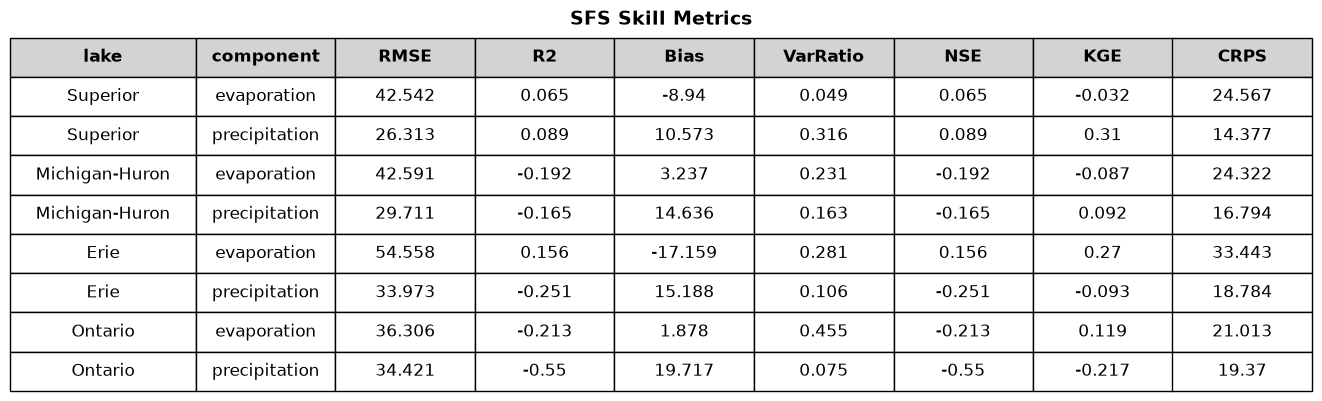

In [39]:
sfs_skill = (
    sfs_ver
    .groupby([
        "lake",
        #"surface_type",
        "component"
    ])
    .apply(calculate_skill)
    .reset_index()
)

plot_styled_table(sfs_skill, title="SFS Skill Metrics")

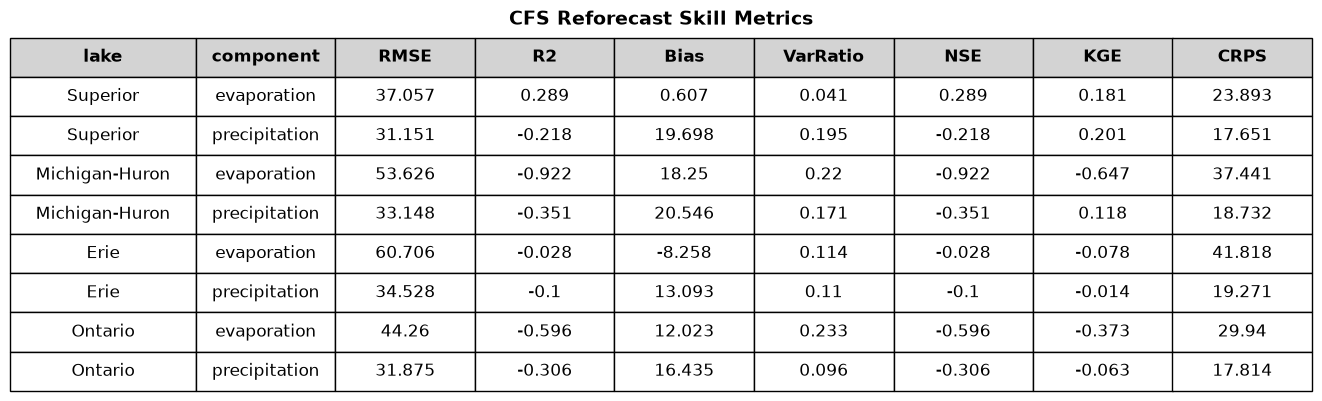

In [40]:
cfsref_skill = (
    cfsref_ver
    .groupby([
        "lake",
        #"surface_type",
        "component"
    ])
    .apply(calculate_skill)
    .reset_index()
)

plot_styled_table(cfsref_skill, title="CFS Reforecast Skill Metrics")

In [ ]:
sfs_skill = sfs_skill.copy()
cfsref_skill = cfsref_skill.copy()

sfs_skill["model"] = "SFS"
cfsref_skill["model"] = "CFS"

skill = pd.concat(
    [sfs_skill, cfsref_skill],
    ignore_index=True
)

skill = skill[
    [
        "model",
        "lake",
        "component",
        "RMSE",
        "R2",
        "Bias",
        "VarRatio",
        "NSE",
        "KGE",
        "CRPS"
    ]
]

                                   RMSE                   R2            \
model                               CFS        SFS       CFS       SFS   
lake           component                                                 
Superior       evaporation    37.057380  42.541969  0.289041  0.064703   
               precipitation  31.151311  26.312605 -0.217695  0.089415   
Michigan-Huron evaporation    53.625846  42.591311 -0.922105 -0.192368   
               precipitation  33.148123  29.711401 -0.351014 -0.165076   
Erie           evaporation    60.706002  54.557838 -0.028021  0.156142   
               precipitation  34.528130  33.972735 -0.099850 -0.250966   
Ontario        evaporation    44.260035  36.305605 -0.595526 -0.212775   
               precipitation  31.875433  34.420878 -0.305548 -0.550457   

                                   Bias             VarRatio            \
model                               CFS        SFS       CFS       SFS   
lake           component             

In [55]:
import numpy as np
import pandas as pd

# ---------------------------------------------------------
# Create comparison table
# ---------------------------------------------------------

skill_compare = skill.pivot(
    index=["lake", "component"],
    columns="model",
    values=[
        "RMSE",
        "R2",
        "Bias",
        "VarRatio",
        "NSE",
        "KGE",
        "CRPS"
    ]
)

skill_compare.index.names = [None, None]
skill_compare.columns.names = [None, None]

# ---------------------------------------------------------
# Function to highlight the better CFS/SFS value
# ---------------------------------------------------------

def highlight_best(data):

    styles = pd.DataFrame(
        "",
        index=data.index,
        columns=data.columns
    )

    metrics = [
        "RMSE",
        "R2",
        "Bias",
        "VarRatio",
        "NSE",
        "KGE",
        "CRPS"
    ]

    for metric in metrics:

        cfs = data[(metric, "CFS")]
        sfs = data[(metric, "SFS")]

        # Determine which direction is better
        if metric in ["RMSE", "CRPS"]:
            cfs_better = cfs < sfs
            sfs_better = sfs < cfs

        elif metric in ["R2", "NSE", "KGE"]:
            cfs_better = cfs > sfs
            sfs_better = sfs > cfs

        elif metric == "Bias":
            cfs_better = abs(cfs) < abs(sfs)
            sfs_better = abs(sfs) < abs(cfs)

        elif metric == "VarRatio":
            cfs_better = abs(cfs - 1) < abs(sfs - 1)
            sfs_better = abs(sfs - 1) < abs(cfs - 1)

        # Light green fill + green outline
        styles.loc[cfs_better, (metric, "CFS")] = (
            "background-color: #d9f2d9; "
            "border: 2px solid #32a852;"
        )

        styles.loc[sfs_better, (metric, "SFS")] = (
            "background-color: #d9f2d9; "
            "border: 2px solid #32a852;"
        )

        # Highlight ties
        tie = ~(cfs_better | sfs_better)

        styles.loc[tie, (metric, "CFS")] = (
            "background-color: #d9f2d9; "
            "border: 2px solid #32a852;"
        )

        styles.loc[tie, (metric, "SFS")] = (
            "background-color: #d9f2d9; "
            "border: 2px solid #32a852;"
        )

    return styles


# ---------------------------------------------------------
# Format the table
# ---------------------------------------------------------

styled_skill = (
    skill_compare
    .style
    .apply(highlight_best, axis=None)
    .format("{:.2f}")
    .set_properties(**{
        "text-align": "center",
        "padding": "6px",
        "border": "1px solid #cccccc"
    })
    .set_table_styles([
        {
            "selector": "th",
            "props": [
                ("font-weight", "bold"),
                ("text-align", "center"),
                ("border", "1px solid #cccccc"),
                ("padding", "6px")
            ]
        },
        {
            "selector": "td",
            "props": [
                ("border", "1px solid #cccccc"),
                ("padding", "6px")
            ]
        }
    ])
)

styled_skill = (
    skill_compare
    .style
    .apply(highlight_best, axis=None)
    .format("{:.2f}")
    .set_properties(**{
        "text-align": "center",
        "padding": "6px",
        "border": "1px solid #cccccc"
    })
    .set_table_styles([
        {
            "selector": "th",
            "props": [
                ("font-weight", "bold"),
                ("text-align", "center"),
                ("border", "1px solid #cccccc"),
                ("padding", "6px")
            ]
        },
        {
            "selector": "td",
            "props": [
                ("border", "1px solid #cccccc"),
                ("padding", "6px")
            ]
        }
    ])
)

styled_skill
